[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jeremydwong/bonelab_inverse_dynamics/blob/main/notebooks/legacy_error_math.ipynb)

# The Mathematics of Three Inverse-Dynamics Errors

The legacy MATLAB pipeline contained three distinct mathematical errors, each
of which survives casual inspection because level walking hides it. This
notebook derives each one from first principles — the correct statement, the
exact point where the legacy code diverges, and what the divergence costs —
with a numerical check after every claim so you can verify each step yourself.

Work through the markdown by hand first; run the cell below it to check.

No data files are needed — everything here is built from the equations.

```bash
uv run jupyter lab notebooks/legacy_error_math.ipynb          # interactive
uv run jupyter nbconvert --to script notebooks/legacy_error_math.ipynb  # -> .py
```

In [1]:
# Colab bootstrap — a no-op when running locally in the uv environment.
import sys, subprocess
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "boneid @ git+https://github.com/jeremydwong/bonelab_inverse_dynamics"],
                   check=True)

import numpy as np
np.set_printoptions(precision=4, suppress=True)

def rot_y(a):
    """Rotation about +y by angle a."""
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])

def rot_x(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])

def rot_z(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])

def skew(w):
    """The matrix such that skew(w) @ v == np.cross(w, v)."""
    return np.array([[0, -w[2], w[1]], [w[2], 0, -w[0]], [-w[1], w[0], 0]])

## Error 1 — rotating the inertia tensor on one side only

### Setup: what the inertia tensor *is*

For a rigid body rotating with angular velocity $\boldsymbol\omega$, the
angular momentum about its centre of mass is

$$\mathbf{L} = I\,\boldsymbol\omega .$$

$I$ is a **linear map from angular velocity to angular momentum**, and like
any linear map its matrix depends on the coordinate frame both vectors are
written in. In the body's own frame — where it is constant, and diagonal if
the axes are principal — call it $I_b$. In the lab frame call it $I_w(t)$;
it changes as the body rotates.

### The transformation rule

Let $R$ be the rotation taking body coordinates to world coordinates:
$\mathbf v_w = R\,\mathbf v_b$ for any vector $\mathbf v$, and therefore
$\mathbf v_b = R^{\mathsf T}\mathbf v_w$ (orthogonality: $R^{-1}=R^{\mathsf T}$).

Now demand that the *physics* be frame-independent. In body coordinates,
$\mathbf L_b = I_b\,\boldsymbol\omega_b$. Express both sides in world
coordinates:

$$
\mathbf L_w \;=\; R\,\mathbf L_b
        \;=\; R\, I_b\,\boldsymbol\omega_b
        \;=\; R\, I_b\, R^{\mathsf T}\,\boldsymbol\omega_w .
$$

Reading off the map from $\boldsymbol\omega_w$ to $\mathbf L_w$:

$$\boxed{\,I_w = R\, I_b\, R^{\mathsf T}\,}$$

Read it as a pipeline: $R^{\mathsf T}$ **translates the input** into the
frame the tensor understands, $I_b$ applies the tensor, $R$ **translates the
answer back**. The legacy code computed $R\,I_b$ — a machine that eats
*body*-frame vectors and emits *world*-frame vectors. That object is not the
inertia tensor in any frame.

In [2]:
# Check: R I R^T maps world-frame omega to the correct world-frame L,
# while R I does not.
I_b = np.diag([4.0, 4.0, 1.0])           # a rod: long axis = body z
R = rot_x(np.deg2rad(90))                # body z now points along world y
w_w = np.array([0.0, 2.0, 0.0])          # spin about world y = the long axis

# ground truth, computed the long way: to body frame, apply I, back to world
L_true = R @ (I_b @ (R.T @ w_w))
L_similarity = (R @ I_b @ R.T) @ w_w
L_onesided   = (R @ I_b) @ w_w           # the legacy object

print("L (ground truth)      :", L_true)
print("L via R I R^T         :", L_similarity)
print("L via R I  (legacy)   :", L_onesided)
# spinning about the long axis, |L| should use the SMALL moment (1), not 4:
print("|L| correct =", np.linalg.norm(L_true), " legacy =", np.linalg.norm(L_onesided))

L (ground truth)      : [0. 2. 0.]
L via R I R^T         : [0. 2. 0.]
L via R I  (legacy)   : [0. 0. 8.]
|L| correct = 2.0  legacy = 8.0


### Three properties the one-sided product destroys

**Symmetry.** Every inertia tensor is symmetric ($I_{ij}=\int \rho\,(...)$ is
symmetric in $i,j$ by construction). The correct transform preserves it:

$$(R I R^{\mathsf T})^{\mathsf T} = R\, I^{\mathsf T} R^{\mathsf T} = R\,I\,R^{\mathsf T}. \checkmark$$

The one-sided product does not: $(RI)^{\mathsf T} = I R^{\mathsf T} \ne RI$
in general (equality would need $I$ to commute with $R$, which happens only
when the rotation axis is a symmetry axis of $I$).

**Spectrum.** $R I R^{\mathsf T}$ is an orthogonal similarity: eigenvalues
(the principal moments) and trace are invariant — rotating a body cannot
change its principal moments. $RI$ has eigenvalues that wander with
orientation and can become complex.

**Positive definiteness.** $\boldsymbol\omega^{\mathsf T} I_w\,
\boldsymbol\omega = 2\,T_{rot} > 0$ for any $\boldsymbol\omega \ne 0$ —
rotational kinetic energy. The similarity transform preserves this; the
one-sided product can produce $\boldsymbol\omega^{\mathsf T}(RI)\boldsymbol\omega \le 0$:
a body whose "kinetic energy" goes negative.

In [3]:
# Check all three properties over random rotations.
rng = np.random.default_rng(0)
I_b = np.diag([4.0, 2.0, 1.0])
worst_asym, worst_eig, worst_energy = 0.0, 0.0, np.inf
for _ in range(500):
    a = rng.uniform(0, 2 * np.pi, 3)
    R = rot_z(a[0]) @ rot_x(a[1]) @ rot_y(a[2])
    good, bad = R @ I_b @ R.T, R @ I_b
    worst_asym = max(worst_asym, np.abs(bad - bad.T).max())
    assert np.abs(good - good.T).max() < 1e-12          # symmetric, always
    assert np.allclose(np.sort(np.linalg.eigvalsh(good)), [1, 2, 4])
    worst_eig = max(worst_eig, np.abs(np.sort_complex(
        np.linalg.eigvals(bad)) - [1, 2, 4]).max())
    w = rng.normal(size=3)
    worst_energy = min(worst_energy, w @ bad @ w / (w @ w))
print(f"one-sided product: worst asymmetry {worst_asym:.2f}, "
      f"worst eigenvalue drift {worst_eig:.2f}, "
      f"most negative 'energy' quotient {worst_energy:.2f}")
print("similarity transform: symmetric, eigenvalues (1,2,4), positive — always")

one-sided product: worst asymmetry 5.89, worst eigenvalue drift 4.99, most negative 'energy' quotient -3.96
similarity transform: symmetric, eigenvalues (1,2,4), positive — always


### What it costs, as a function of orientation

The torque error from using $RI$ instead of $RIR^{\mathsf T}$ is
$\Delta\mathbf M = (RI - RIR^{\mathsf T})\,\boldsymbol\alpha + \ldots$ — it
depends on the body's orientation, so within a stride it **waxes and wanes**
as each segment rotates. Two limits are worth knowing:

- $R = \mathbb{1}$ (segment aligned with the lab): $RI = RIR^{\mathsf T} = I$,
  **zero error**. Near-upright segments in quiet standing hide the bug.
- Rotation about a principal axis of $I$ by angle $\theta$: the error grows
  with $\theta$ and with the *anisotropy* of $I$ (for a sphere,
  $I \propto \mathbb 1$ commutes with everything: no error, ever).

Run the cell to see the error's orientation dependence for a shank-like rod.

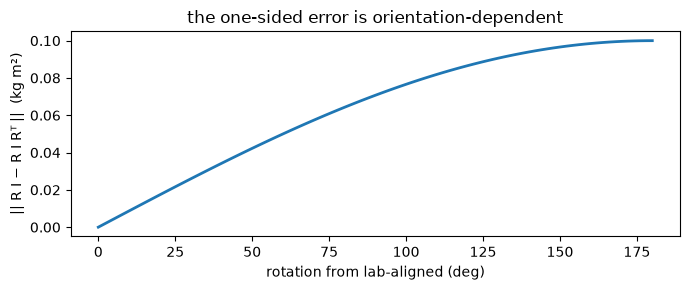

In [4]:
# |R I - R I R^T| (operator norm) vs rotation angle about world x,
# for a shank-like tensor. Note the zero at 0 and the growth with angle.
I_b = np.diag([0.05, 0.05, 0.003])       # shank-ish, kg m^2
angles = np.linspace(0, np.pi, 91)
err = [np.linalg.norm(rot_x(a) @ I_b - rot_x(a) @ I_b @ rot_x(a).T, ord=2)
       for a in angles]
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(np.degrees(angles), err, lw=2)
ax.set_xlabel("rotation from lab-aligned (deg)")
ax.set_ylabel("|| R I − R I Rᵀ ||  (kg m²)")
ax.set_title("the one-sided error is orientation-dependent")
fig.tight_layout(); display(fig); plt.close(fig)

## Error 2 — Euler's equation without its gyroscopic term

### The correct statement, derived

Torque about the centre of mass equals the rate of change of angular
momentum, **in an inertial (lab) frame**:

$$\mathbf M = \frac{d\mathbf L}{dt}, \qquad \mathbf L = I_w(t)\,\boldsymbol\omega(t).$$

Both factors depend on time — the body rotates, so $I_w$ rotates with it.
Product rule:

$$\mathbf M = I_w\,\dot{\boldsymbol\omega} + \dot I_w\,\boldsymbol\omega
            = I_w\,\boldsymbol\alpha + \dot I_w\,\boldsymbol\omega .$$

For $\dot I_w$, differentiate $I_w = R I_b R^{\mathsf T}$ using
$\dot R = \Omega R$ where $\Omega = \mathrm{skew}(\boldsymbol\omega)$
(that identity *defines* angular velocity):

$$
\dot I_w = \dot R I_b R^{\mathsf T} + R I_b \dot R^{\mathsf T}
         = \Omega\, R I_b R^{\mathsf T} + R I_b R^{\mathsf T} \Omega^{\mathsf T}
         = \Omega\, I_w - I_w\, \Omega .
$$

Apply to $\boldsymbol\omega$ and note $\Omega\,\boldsymbol\omega =
\boldsymbol\omega \times \boldsymbol\omega = 0$, so the second term drops:

$$\dot I_w\,\boldsymbol\omega = \Omega\, I_w \boldsymbol\omega
  = \boldsymbol\omega \times (I_w\,\boldsymbol\omega).$$

Hence Euler's equation in lab coordinates:

$$\boxed{\;\mathbf M = I_w\,\boldsymbol\alpha
        + \boldsymbol\omega \times (I_w\,\boldsymbol\omega)\;}$$

The legacy `inv3d.m` used $\mathbf M = I\boldsymbol\alpha$ — the first term
alone.

In [5]:
# Check the operator identity dI_w/dt = Omega I_w - I_w Omega numerically,
# by finite-differencing I_w(t) along an arbitrary rotation history.
dt = 1e-6
I_b = np.diag([0.4, 0.2, 0.1])
w = np.array([1.3, -0.7, 2.1])           # constant world omega for the test
axis = w / np.linalg.norm(w)
def R_of(t):
    th = np.linalg.norm(w) * t
    K = skew(axis)
    return np.eye(3) + np.sin(th) * K + (1 - np.cos(th)) * (K @ K)
t0 = 0.37
I_w = lambda t: R_of(t) @ I_b @ R_of(t).T
dI_num = (I_w(t0 + dt) - I_w(t0 - dt)) / (2 * dt)
Om = skew(w)
dI_ana = Om @ I_w(t0) - I_w(t0) @ Om
print("max |numeric − analytic| dI_w/dt:", np.abs(dI_num - dI_ana).max())
# ...and the torque it implies at constant omega (alpha = 0):
L = I_w(t0) @ w
print("required torque  dL/dt =", (I_w(t0 + dt) @ w - I_w(t0 - dt) @ w) / (2 * dt))
print("omega x (I_w omega)    =", np.cross(w, L))
print("legacy I*alpha         =", I_w(t0) @ np.zeros(3))

max |numeric − analytic| dI_w/dt: 3.131390979849158e-11
required torque  dL/dt = [-0.4997  0.4994  0.4758]
omega x (I_w omega)    = [-0.4997  0.4994  0.4758]
legacy I*alpha         = [0. 0. 0.]


### The physical picture

Spin a body at **constant** $\boldsymbol\omega$ about an axis that is *not*
principal. Then $\boldsymbol\alpha = 0$, so the legacy formula demands zero
torque. But $\mathbf L = I_w\boldsymbol\omega$ is not parallel to
$\boldsymbol\omega$ (that alignment is exactly what "principal axis" means),
and as the body turns, $\mathbf L$ sweeps a cone around the rotation axis.
A rotating vector of constant length changes at rate
$\boldsymbol\omega \times \mathbf L$ — which is precisely the gyroscopic
term. Whoever holds the axle feels that torque. (Let go, and the body
redistributes the motion instead: the tennis-racket tumble.)

### Why walking almost forgives it

The term vanishes when $\boldsymbol\omega$ lies along a principal axis. In
gait, each leg segment's $\boldsymbol\omega$ rides overwhelmingly on its
medio-lateral (flexion) axis — a principal axis of a near-axisymmetric
segment. On the real p1 data the shank spends ~83% of $|\boldsymbol\omega|$
on that one axis and the peak $|\boldsymbol\omega \times I\boldsymbol\omega|$
over the whole leg is ≈1.6 N·m against ≈126 N·m joint torques. The cell
below reproduces the scaling with a two-line model you can play with.

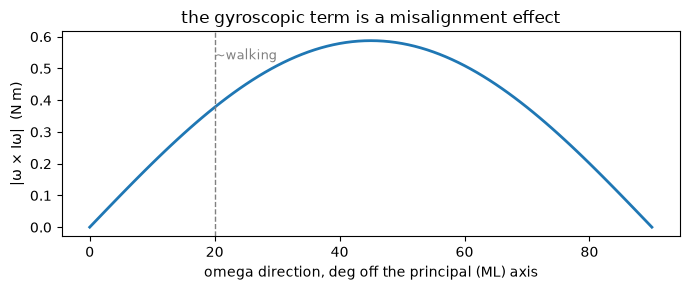

at 20° tilt: 0.38 N m — against ~100 N m joint torques


In [6]:
# Gyroscopic magnitude for a shank-like segment as the omega direction
# tilts off the principal (ML) axis. In walking the tilt is small.
I_b = np.diag([0.05, 0.05, 0.003])       # transverse, transverse, longitudinal
w_mag = 5.0                               # rad/s, swing-phase shank is ~4-7
tilts = np.linspace(0, 90, 91)            # deg off the ML principal axis
gyro = []
for td in tilts:
    t = np.deg2rad(td)
    w = w_mag * np.array([np.cos(t), 0.0, np.sin(t)])  # ML -> longitudinal mix
    gyro.append(np.linalg.norm(np.cross(w, I_b @ w)))
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(tilts, gyro, lw=2)
ax.axvline(20, color="gray", ls="--", lw=1)
ax.annotate("~walking", (20, max(gyro) * 0.9), fontsize=9, color="gray")
ax.set_xlabel("omega direction, deg off the principal (ML) axis")
ax.set_ylabel("|ω × Iω|  (N m)")
ax.set_title("the gyroscopic term is a misalignment effect")
fig.tight_layout(); display(fig); plt.close(fig)
print(f"at 20° tilt: {gyro[20]:.2f} N m — against ~100 N m joint torques")

## Error 3 — Cardan-angle second derivatives are not angular acceleration

### What angular velocity actually is

$\boldsymbol\omega$ is defined through $\dot R = \mathrm{skew}(\boldsymbol\omega)\,R$.
It is a genuine vector: it adds, it crosses, Euler's equation consumes it.

A Cardan (Euler) angle triplet $\boldsymbol\theta = (\theta_1,\theta_2,\theta_3)$
— say the z-x-y sequence the legacy code used, $R = R_z(\theta_1)R_x(\theta_2)R_y(\theta_3)$
— is a *chart* on the rotation group: three numbers that name the
orientation. Their time-derivatives $\dot{\boldsymbol\theta}$ are **rates of
chart coordinates**, and each rate turns about a *different, generally
non-orthogonal axis*: $\dot\theta_1$ about the lab z, $\dot\theta_2$ about
the once-rotated x, $\dot\theta_3$ about the twice-rotated y. Collecting
those axes as columns of a matrix $E(\boldsymbol\theta)$:

$$\boldsymbol\omega = E(\boldsymbol\theta)\,\dot{\boldsymbol\theta},
\qquad E = \big[\,\hat{\mathbf z} \;\big|\; R_z\hat{\mathbf x} \;\big|\; R_zR_x\hat{\mathbf y}\,\big].$$

$E$ is orientation-dependent, is not orthogonal, and loses rank at gimbal
lock ($\theta_2 = \pm 90°$).

### The correct angular acceleration — and the legacy one

Differentiate:

$$\boldsymbol\alpha = \dot{\boldsymbol\omega}
   = E\,\ddot{\boldsymbol\theta} + \dot E\,\dot{\boldsymbol\theta}.$$

The legacy pipeline (via the lost `RoomSegAng.m`, inferred from its usage)
used $\ddot{\boldsymbol\theta}$ itself as "$\boldsymbol\alpha$". That is two
errors at once: it **drops the $\dot E\dot{\boldsymbol\theta}$ term**
(products of rates — zero only when at most one angle moves), and it
**feeds chart components into a vector slot** — $\ddot\theta$'s components
live on the three skew axes, not on the lab axes, so even the $E\ddot\theta$
part is mis-assembled unless $E \approx \mathbb 1$.

### When it is forgiven

If the motion is planar (only one Cardan angle changes) *and* the moving
axis is a lab axis, then $E$ restricted to that angle is a constant unit
vector and $\ddot\theta$ *is* the angular acceleration component. That is
the small/planar-rotation limit — and it is, approximately, sagittal-plane
gait. Out-of-plane motion breaks both assumptions at once.

In [7]:
# Build E(theta) for the z-x-y sequence and check omega = E(theta) thetadot
# against the definition omega = unskew(Rdot R^T), on a 3D angle history.
def R_zxy(th):
    return rot_z(th[0]) @ rot_x(th[1]) @ rot_y(th[2])

def E_zxy(th):
    z_axis = np.array([0.0, 0.0, 1.0])
    x1 = rot_z(th[0]) @ np.array([1.0, 0.0, 0.0])
    y2 = rot_z(th[0]) @ rot_x(th[1]) @ np.array([0.0, 1.0, 0.0])
    return np.column_stack([z_axis, x1, y2])

rate = 2000.0
t = np.arange(int(rate)) / rate
A = np.array([0.5, 0.4, 0.6])            # rad, genuinely 3-D motion
F = np.array([1.0, 1.7, 0.9])            # Hz
th  = A * np.sin(2 * np.pi * F * t[:, None])
thd = A * 2 * np.pi * F * np.cos(2 * np.pi * F * t[:, None])

k = 700
R0, R1 = R_zxy(th[k - 1]), R_zxy(th[k + 1])
w_def_hat = (R1 - R0) / (2 / rate) @ R_zxy(th[k]).T
w_def = np.array([w_def_hat[2, 1], w_def_hat[0, 2], w_def_hat[1, 0]])
w_map = E_zxy(th[k]) @ thd[k]
print("omega via Rdot R^T :", w_def)
print("omega via E thetad :", w_map)
print("E at this instant (columns = the three rate axes):")
print(E_zxy(th[k]))
print("E is not orthogonal: E^T E =")
print(E_zxy(th[k]).T @ E_zxy(th[k]))

omega via Rdot R^T : [-2.7316 -2.5983 -1.5462]
omega via E thetad : [-2.7316 -2.5983 -1.5462]
E at this instant (columns = the three rate axes):
[[ 0.      0.9193 -0.3837]
 [ 0.      0.3936  0.8962]
 [ 1.      0.     -0.2229]]
E is not orthogonal: E^T E =
[[ 1.      0.     -0.2229]
 [ 0.      1.      0.    ]
 [-0.2229  0.      1.    ]]


In [8]:
# Now alpha: truth = d(omega)/dt vs the legacy thetaddot, as the motion
# goes from planar (only theta_2 active) to fully 3-D.
def alpha_compare(amps):
    A = np.asarray(amps, float)
    th  = A * np.sin(2 * np.pi * F * t[:, None])
    # true omega at every sample via the definition, then differentiate
    w = np.empty((len(t), 3))
    for i in range(len(t)):
        w[i] = E_zxy(th[i]) @ (A * 2 * np.pi * F * np.cos(2 * np.pi * F * t[i]))
    alpha_true = np.gradient(w, 1 / rate, axis=0)
    thdd = -A * (2 * np.pi * F) ** 2 * np.sin(2 * np.pi * F * t[:, None])
    err = np.linalg.norm(alpha_true - thdd, axis=1)
    scale = np.abs(alpha_true).max()
    return err[50:-50].max(), scale

for amps, label in [((0.0, 0.5, 0.0), "planar (one lab-ish axis)"),
                    ((0.1, 0.5, 0.1), "mildly 3-D (walking-like)"),
                    ((0.5, 0.4, 0.6), "fully 3-D")]:
    e, s = alpha_compare(amps)
    print(f"{label:28s}: max |alpha_true − thetadd| = {e:7.2f} rad/s² "
          f"({100 * e / s:.1f}% of peak alpha)")

planar (one lab-ish axis)   : max |alpha_true − thetadd| =   80.68 rad/s² (141.4% of peak alpha)
mildly 3-D (walking-like)   : max |alpha_true − thetadd| =   88.89 rad/s² (156.4% of peak alpha)
fully 3-D                   : max |alpha_true − thetadd| =   97.16 rad/s² (223.9% of peak alpha)


## Why level walking forgave all three at once

Collect the three forgiveness conditions:

| error | vanishes when | walking supplies |
|---|---|---|
| 1: $RI$ vs $RIR^{\mathsf T}$ | segment lab-aligned, or $I$ isotropic about the rotation axis | segments near-sagittal, rotating about a symmetry-adjacent axis |
| 2: missing $\boldsymbol\omega \times I\boldsymbol\omega$ | $\boldsymbol\omega$ on a principal axis | ~80% of $|\boldsymbol\omega|$ on the ML principal axis |
| 3: $\ddot{\boldsymbol\theta}$ as $\boldsymbol\alpha$ | one angle active, about a fixed lab axis | motion dominated by sagittal flexion |

And one more, which is the deepest: in level walking the **whole inertial
moment term is a small fraction of the joint-torque balance** — the balance
is dominated by the ground reaction's moment arm. Errors inside a small term
stay small. Measured on subject P1 (trial 13, 1.72 m/s), the full legacy
physics moves the ankle torque by ~0.3% of peak, the knee by ~1–2%, and the
hip by ~5–6% (up to 22 N·m) — and the reproduced errors 1 and 3 partially
*cancel* at the right hip, which is luck, not structure. The moment any of
the three conditions breaks — turning, crossover, non-sagittal sport
movements, robotics — the errors surface at full size.

The executable A/B on real data is `uv run python -m boneid.report asics`;
the guarding tests are `KEY-GYRO` (errors 1+2) and
`tests/test_asicssource.py` (all three, including proof that the faithful
re-implementation *fails* the gyroscope case the corrected code passes).

In [9]:
# The whole story in one number each, using the package itself.
from boneid.core import AnalysisParams, inverse_dynamics
from boneid.simulate import simulate_gyro
skel, kin, ground, truth = simulate_gyro()
res = inverse_dynamics(skel, kin, ground, AnalysisParams(lowpass_hz=0, force_lowpass_hz=0))
i = slice(5, -5)
err_correct = np.abs(res.residual_torque[i] - truth[i]).max()
err_legacy = np.abs(truth[i]).max()      # legacy predicts ~zero torque here
print(f"KEY-GYRO: required torque peak {np.abs(truth).max():.3f} N m")
print(f"  corrected pipeline error : {err_correct:.2e} N m")
print(f"  legacy (I*alpha = 0) miss: {err_legacy:.3f} N m — the full term")

KEY-GYRO: required torque peak 1.800 N m
  corrected pipeline error : 7.80e-06 N m
  legacy (I*alpha = 0) miss: 1.800 N m — the full term
